In [59]:
import pandas as pd
url ='https://raw.githubusercontent.com/pia222sk20/python_src/refs/heads/main/data/titanic.csv'
titanic = pd.read_csv(url)
titanic = titanic.rename(columns={'Sex':'Gender'})
titanic.head(2)

# 해당되는 컬럼이 어떤 특성을 가졌는지 파악하고 나아가기

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


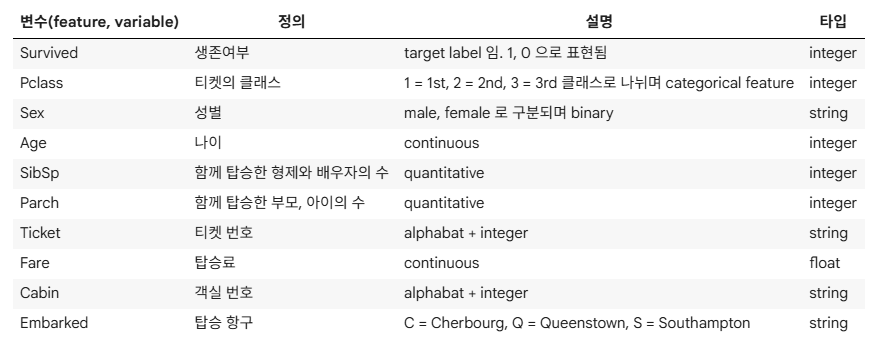

In [60]:
# 결측치 확인 (1) - info 사용
titanic.info()
# age, cabin, embarked 에 결측치가 있는 것으로 예상된다.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Gender       891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [61]:
# 결측치 확인 (2) - describe() 사용
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [62]:
titanic.describe(include='object')

,Name,Gender,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


In [63]:
# null check
titanic.isna().sum()

titanic.isna().mean() #합이아닌 평균값을 구하는 이유,
#예를 들어 Age 열이 20% 정도 결측이라면:
titanic['Age'].isna().mean()
# # 0.20 → 전체 행의 20%가 결측
# 그래서 .mean()을 쓰는 이유는
# “단순 개수보다 결측 비율을 보는 게 더 직관적” 이기 때문이에요. (데이터 크기에 상관없이 비교 가능)

np.float64(0.19865319865319866)

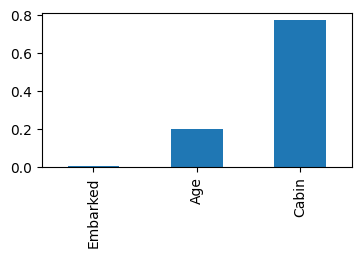

In [64]:
titanic.isna().mean().sort_values(ascending=False)

import matplotlib.pyplot as plt
plt.figure(figsize=(4, 2))  
temp = titanic.isna().mean()
temp[temp>0].sort_values().plot(kind='bar')
plt.show()

In [65]:
%pip install missingno

Note: you may need to restart the kernel to use updated packages.


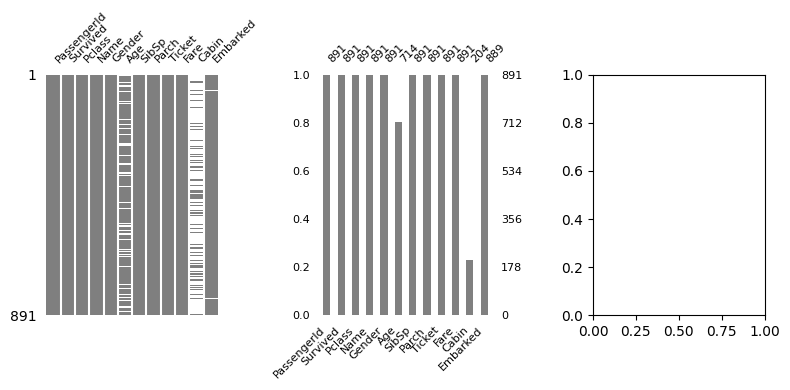

In [69]:
import missingno as msno

fig,axes = plt.subplots(1,3,figsize=(8,4))

msno.matrix(df=titanic,figsize=(4,4),fontsize=8,color=(0.5, 0.5, 0.5),ax=axes[0],sparkline=False)
msno.bar(df=titanic,figsize=(4,4),fontsize=8,color=(0.5, 0.5, 0.5),ax=axes[1])
plt.tight_layout()
plt.show()

In [ ]:
# age 컬럼의 결촉치가 있는 모든 row를 출력
# titanic[titanic['Age'].isna()]
# titanic[titanic['Age'].isnull()]

#Age 컬럼이 실제로 NaN이 아닌 다른 결측치 표현을 쓰는 경우, isna()만으로는 결측치가 보이지가 않는다.
# 예: 빈 문자열 ""이나 "NA", None 등
# 이런 경우 isna()는 np.nan만 True로 인식하므로, 실제 결측치처럼 보이는 값이 걸러지지 않아

# 추천 명령어?
# 빈 문자열을 결측치로 간주
# titanic[titanic['Age'].isin(['', 'NA', 'unknown'])]
# 모든 잠재적 결측치를 NaN으로 통일
# titanic['Age'].replace(['', 'NA', 'unknown'], np.nan, inplace=True)


,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S


In [ ]:
missing_df = titanic[titanic.drop(columns=['Cabin']).isna().any(axis=1)]
missing_df.head()
#Cabin 컬럼이 삭제된 이유: Titanic 데이터셋에서 Cabin 컬럼은 결측치 비율이 매우 높기 때문.
# 만약 제거하지 않고 .any(axis=1) 하면 거의 모든 행이 선택될 가능성이 있음 → 의미 없는 결과가 됨.

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q


In [82]:
# Embarked 가 결측치인 row 데이터를 출력
missing_df2_index = titanic[titanic['Embarked'].isna()].index
# titanic[titanic.Embarked.isna()]

In [86]:
k=3
df_lists =[]
for i in missing_df2_index:
    df_lists.append(titanic.loc[i-k:i+k])
pd.concat(df_lists)

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
58,59,1,2,"West, Miss. Constance Mirium",female,5.00,1,2,C.A. 34651,27.7500,NaN,S
59,60,0,3,"Goodwin, Master. William Frederick",male,11.00,5,2,CA 2144,46.9000,NaN,S
60,61,0,3,"Sirayanian, Mr. Orsen",male,22.00,0,0,2669,7.2292,NaN,C
61,62,1,1,"Icard, Miss. Amelie",female,38.00,0,0,113572,80.0000,B28,NaN
62,63,0,1,"Harris, Mr. Henry Birkhardt",male,45.00,1,0,36973,83.4750,C83,S
63,64,0,3,"Skoog, Master. Harald",male,4.00,3,2,347088,27.9000,NaN,S
64,65,0,1,"Stewart, Mr. Albert A",male,NaN,0,0,PC 17605,27.7208,NaN,C
826,827,0,3,"Lam, Mr. Len",male,NaN,0,0,1601,56.4958,NaN,S
827,828,1,2,"Mallet, Master. Andre",male,1.00,0,2,S.C./PARIS 2079,37.0042,NaN,C
828,829,1,3,"McCormack, Mr. Thomas Joseph",male,NaN,0,0,367228,7.7500,NaN,Q


In [ ]:
import matplotlib.pyplot as plt # 폰트관련 기능, 폰트를 수정할려면 이기능이 필요하다.

# matplotlib 한글 폰트 오류 문제 해결
from matplotlib import font_manager, rc
font_path = "C:\김지은\파이썬_src\pandas-data-analysis\part4\data\scatter_transparent.png"   # 폰트파일의 위치
                                  # Windows - Fonts
font_name = font_manager.FontProperties(fname=font_path).get_name()
# .get_name() : 폰트가 시스템에서 인식하는 이름을 가져옵니다.
# get_name() → .ttf 파일에서 폰트 이름(패밀리명) 추출
# 그 이름을 family에 넣으면 → matplotlib이 해당 폰트를 기본으로 사용
print(font_name) # Malgun Gothic
rc('font', family=font_name)


c:\김지은\파이썬_src\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\김지은\파이썬_src\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51316 (\N{HANGUL SYLLABLE JON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\김지은\파이썬_src\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\김지은\파이썬_src\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47932 (\N{HANGUL SYLLABLE MUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


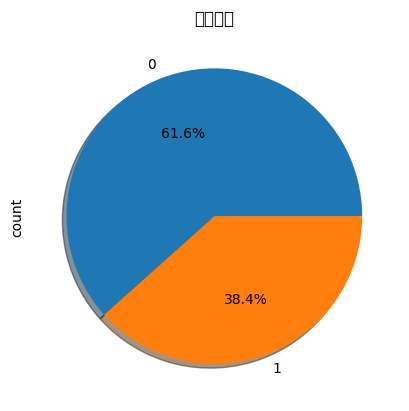

In [109]:
# 서브플롯이 있을 때
# 파이 그래프
titanic.Survived.value_counts().plot.pie(
    autopct='%1.1f%%',
    shadow=True
)
plt.title('생존인물')
plt.show()

In [ ]:
# 선실등급별 생존유무
titanic.groupby('Pclass')['Survived'].sum()

Pclass
1    136
2     87
3    119
Name: Survived, dtype: int64

In [101]:
pd.crosstab(titanic['Pclass'],titanic['Survived'],margins=True).style.background_gradient()

Survived,0,1,All
Pclass,,,
1,80,136,216
2,97,87,184
3,372,119,491
All,549,342,891
